# Upload a large fine-tuning dataset in parts

Upload a multi-gigabyte training file to Crusoe with the multipart path in the OpenAI-compatible [Uploads API](https://docs.crusoecloud.com/api/managed-ai/#tag/Uploads), then hand the assembled file to a fine-tuning job. The file is split into parts that are sent in parallel, the upload is completed with a checksum, and Crusoe assembles the parts in the background into a regular file id.

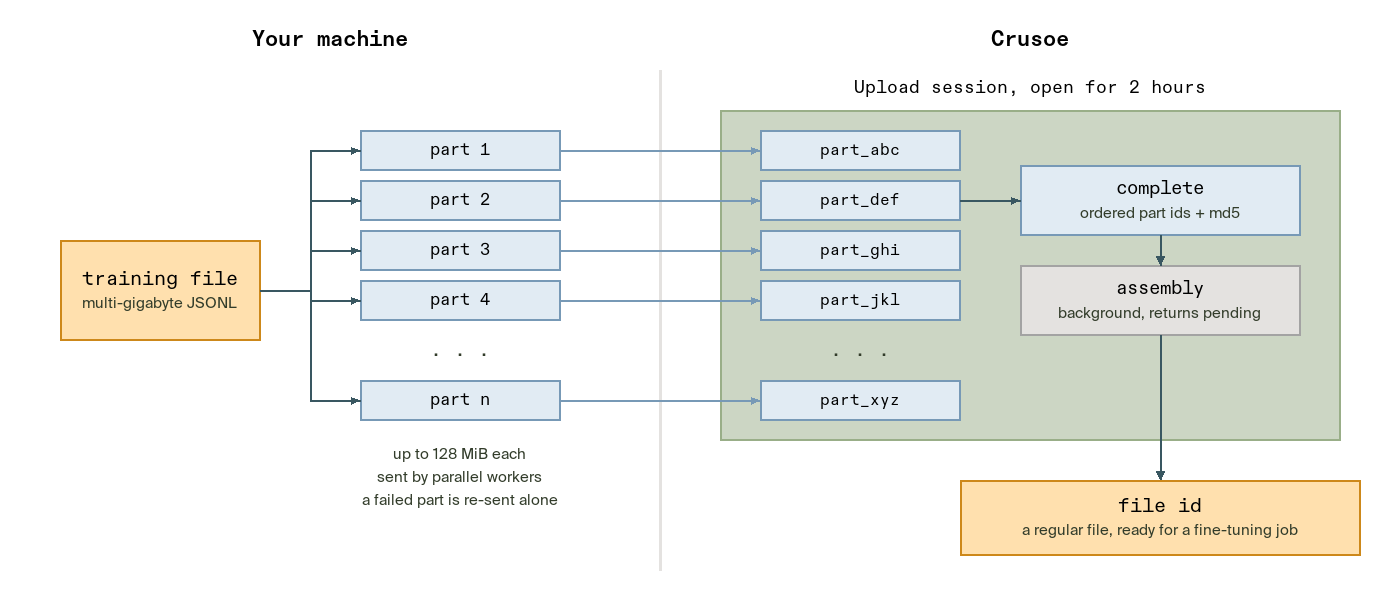

## Setup

Paste two tokens below: a Crusoe API key from the Console under [Inference API keys](https://console.crusoecloud.com/security/inference-api-keys), and a Hugging Face token from [Access Tokens](https://huggingface.co/settings/tokens) for the dataset download. Helpers for the dataset export, part reading, parallel sends, and polling live in [utils.py](utils.py).

In [ ]:
import os

import requests
from openai import OpenAI

import utils

CRUSOE_API_KEY = os.environ.get("CRUSOE_API_KEY", "paste-your-crusoe-api-key-here")
HF_TOKEN = os.environ.get("HF_TOKEN", "paste-your-hugging-face-token-here")

for name, value in (("CRUSOE_API_KEY", CRUSOE_API_KEY), ("HF_TOKEN", HF_TOKEN)):
    if not value or value.startswith("paste-your"):
        raise ValueError(f"Add your token to {name} above")

BASE_URL = "https://api.intelligence.crusoecloud.com/v1"
HEADERS = {"Authorization": f"Bearer {CRUSOE_API_KEY}"}
client = OpenAI(api_key=CRUSOE_API_KEY, base_url=BASE_URL)

MiB = 1024 * 1024
PART_SIZE = 128 * MiB  # Crusoe's ceiling per part
WORKERS = 8            # parts in flight at once; peak RAM is about WORKERS * PART_SIZE

## Prerequisite: Build a large training file

For this example we use [HuggingFaceH4/ultrachat_200k](https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k), a public dataset whose `train_sft` split holds about 208,000 conversations already in the chat format the fine-tuning service expects. Writing them out as JSONL gives a file large enough to need several parts. Any chat-format JSONL of your own works the same way; set `MAX_ROWS` to an integer for a smaller trial file.

In [ ]:
MAX_ROWS = None  # for example 20_000 rows for a quick run of about 115 MB

TRAIN_PATH = utils.build_training_file("HuggingFaceH4/ultrachat_200k", 
                                       "train_sft", 
                                       "data/train.jsonl", 
                                       max_rows=MAX_ROWS, 
                                       token=HF_TOKEN)

FILE_BYTES = TRAIN_PATH.stat().st_size
N_PARTS = utils.part_count(TRAIN_PATH, PART_SIZE)
print(f"{FILE_BYTES / MiB:,.0f} MiB on disk, {N_PARTS} parts of up to {PART_SIZE // MiB} MiB")

1,185 MiB on disk, 10 parts of up to 128 MiB


## Step 1: Create the upload

Declare the filename, purpose, size, and MIME type. The bytes received across all parts must add up to this size at completion. The session stays open for two hours.

In [3]:
upload = client.uploads.create(
    purpose="fine-tune",
    filename=TRAIN_PATH.name,
    bytes=FILE_BYTES,
    mime_type="text/jsonl",
)
print(f"Upload id : {upload.id}")
print(f"Status    : {upload.status}")
print(f"Declared  : {upload.bytes:,} bytes")
print(f"Session   : {(upload.expires_at - upload.created_at) // 3600} hours")

Upload id : upload_d43e7bb6899e4f5f9053ed58094fe824
Status    : pending
Declared  : 1,242,536,347 bytes
Session   : 2 hours


## Step 2: Add the parts in parallel

Each part is an independent request that returns a part id. Parts can go in any order and at the same time; a failed part is re-sent on its own and every retry mints a fresh id.

In [4]:
def send_part(index):
    data = utils.read_part(TRAIN_PATH, index, PART_SIZE)
    part = client.uploads.parts.create(upload_id=upload.id, data=data)
    return index, part.id


part_ids, elapsed = utils.send_in_parallel(send_part, N_PARTS, WORKERS)
print(f"\n{FILE_BYTES / MiB:,.0f} MiB in {elapsed:.0f} s with {WORKERS} workers, about {FILE_BYTES / MiB / elapsed:.0f} MiB/s")

[ 20.5s] part  3/10 landed  part_0ef2939fdf824d70a925f39217aada27
[ 20.7s] part  2/10 landed  part_48fbea3762e64f63b8c0b9199528aa7d


[ 20.7s] part  1/10 landed  part_c0754dcb97c84fee83726847d6d76a84


[ 21.2s] part  4/10 landed  part_f6f2d8d4cb70414bbd0baede5f77d210


[ 24.3s] part  6/10 landed  part_dce9be372e274bff95f11784a65cd6ed


[ 24.9s] part  7/10 landed  part_e2319469dbdb45b283906d5b15c558e5
[ 24.9s] part  5/10 landed  part_298717ad339e44fc9fff2e93dfbd8989


[ 25.2s] part 10/10 landed  part_ac5fc317be4946b98f31a5971507a4e2


[ 25.5s] part  8/10 landed  part_4f344cf9527946d9a7ff2354d8d48314


[ 29.0s] part  9/10 landed  part_e56d4bced62740fbac8bb72570a9cdfb

1,185 MiB in 29 s with 8 workers, about 41 MiB/s


Two REST endpoints show an upload from the outside: the parts Crusoe has received for a session, and the sessions still open.

In [5]:
received = requests.get(f"{BASE_URL}/uploads/{upload.id}/parts", headers=HEADERS).json()
print(f"{len(received['data'])} of {N_PARTS} parts received")

pending = requests.get(f"{BASE_URL}/uploads", headers=HEADERS, params={"status": "pending"}).json()
for session in pending["data"]:
    print(f"pending: {session['id']}  {session['filename']}  {session['bytes']:,} bytes")

10 of 10 parts received


pending: upload_d43e7bb6899e4f5f9053ed58094fe824  train.jsonl  1,242,536,347 bytes


## Step 3: Complete the upload

Pass the part ids in file order and, optionally, the file's MD5 so Crusoe verifies the assembled file. Unlike OpenAI, the call returns `pending` right away and assembly runs in the background.

In [6]:
FILE_MD5 = utils.md5_of(TRAIN_PATH)
completion = client.uploads.complete(upload_id=upload.id, part_ids=part_ids, md5=FILE_MD5)
print(f"md5={FILE_MD5}  status={completion.status}")

md5=c331df73b21e3752cfea8758b11f26f4  status=pending


## Step 4: Poll until the file is ready

Retrieve the upload until its status leaves `pending`. On `completed` the `file` field holds a regular File object; on `failed` the `error` field carries a code such as `checksum_mismatch` or `missing_part`.

In [7]:
state, waited = utils.wait_for_assembly(BASE_URL, HEADERS, upload.id)
if state["status"] != "completed":
    raise RuntimeError(f"assembly {state['status']}: {state.get('error')}")

TRAINING_FILE_ID = state["file"]["id"]
print(f"assembled in {waited:.0f} s")
print(f"file id: {TRAINING_FILE_ID}")

training_file = client.files.retrieve(TRAINING_FILE_ID)
print(f"{training_file.filename}  {training_file.bytes:,} bytes  purpose={training_file.purpose}  status={training_file.status}")

assembled in 17 s
file id: files:file_d43e7bb6899e4f5f9053ed58094fe824:b2b31910-9093-4b1b-8aa4-2fce722b9898:4f668f159fd41045e8919a0ff6cb2e03c87243ea


train.jsonl  1,242,536,347 bytes  purpose=fine-tune  status=uploaded


## Step 5: Use the file in a fine-tuning job

The file id goes wherever a file id goes today. The job is off by default because a run over 208,000 conversations is billed per training token.

In [8]:
SUBMIT_FINE_TUNING_JOB = False
BASE_MODEL_NAME = "Qwen/Qwen3-8B"

if SUBMIT_FINE_TUNING_JOB:
    fine_tunable = [m for m in client.models.list().data if getattr(m, "fine_tuning_available", False)]
    base_model_id = next(m.id for m in fine_tunable if m.model_name == BASE_MODEL_NAME)
    job = client.fine_tuning.jobs.create(model=base_model_id, training_file=TRAINING_FILE_ID, suffix="ultrachat-multipart")
    print(f"{job.id}  status={job.status}")
    print(f"https://console.crusoecloud.com/foundry/fine-tuning/jobs/{job.id}/overview")
else:
    print("Skipped. Set SUBMIT_FINE_TUNING_JOB = True to train on the uploaded file.")

Skipped. Set SUBMIT_FINE_TUNING_JOB = True to train on the uploaded file.


## Step 6: Cancel and clean up

Cancelling a session releases its parts at once; an abandoned session expires after two hours. The assembled file persists until you delete it.

In [9]:
abandoned = client.uploads.create(purpose="fine-tune", filename="abandoned.jsonl", bytes=FILE_BYTES, mime_type="text/jsonl")
print(f"{abandoned.id}  status={client.uploads.cancel(abandoned.id).status}")

upload_bc03a3d2a6214e54aabcacaa7bcd1a41  status=cancelled


In [10]:
DELETE_UPLOADED_FILE = False

if DELETE_UPLOADED_FILE:
    print(client.files.delete(TRAINING_FILE_ID))
else:
    print("Skipped. Set DELETE_UPLOADED_FILE = True to delete the uploaded file.")

Skipped. Set DELETE_UPLOADED_FILE = True to delete the uploaded file.
